# Predicción de Incumplimiento de Pago en Tarjetas de Crédito


#### Descripción General del Proyecto

La predicción de incumplimiento de pago en tarjetas de crédito es una de las aplicaciones más importantes del machine learning en la banca minorista. Identificar con precisión a los clientes con mayor probabilidad de incumplir su próximo pago permite a las instituciones financieras reducir el riesgo crediticio, optimizar las decisiones de otorgamiento de crédito y mejorar la rentabilidad de su portafolio.

Este proyecto desarrolla un modelo de clasificación binaria para predecir si un cliente de tarjeta de crédito incumplirá su próximo pago mensual, utilizando información demográfica, límites de crédito, estados de cuenta, historial de pagos e indicadores financieros construidos a partir de estas variables.

Además de construir un modelo predictivo preciso, el proyecto explora cómo distintas estrategias de ingeniería de características y distintos algoritmos de machine learning afectan el desempeño de la clasificación. Se evalúan varias representaciones de las variables para determinar si agregarlas puede mejorar la predicción o reducir la complejidad del modelo sin sacrificar desempeño.

- **Ingeniería de características:** ¿Las variables orientadas al negocio mejoran el desempeño predictivo?
- **Agregación de características:** ¿Puede resumirse el historial mensual de facturación y pagos sin perder información relevante?
- **Comparación de modelos:** Regresión Logística y Random Forest se evalúan bajo el mismo marco experimental.
- **Optimización de modelos:** Se utilizan validación cruzada, ajuste de hiperparámetros y optimización del umbral de decisión para maximizar el F1-score evitando el sobreajuste.

---

#### Dataset

https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

El dataset contiene **30,000 clientes de tarjetas de crédito** descritos por **23 variables predictoras** y una variable objetivo binaria que indica si el cliente incumplió su próximo pago mensual.

| Clase | Etiqueta | Cantidad | Proporción |
|-------|----------|----------|------------|
| No incumplimiento | 0 | 23364 | 77.88% |
| Incumplimiento | 1 | 6636 | 22.12% |

El dataset presenta un desbalance de clases moderado, el cual se tiene en cuenta a lo largo del entrenamiento y la evaluación de los modelos.

---

#### Métrica de Evaluación

En el riesgo crediticio, ambos tipos de error de clasificación tienen consecuencias financieras:

- Un **falso negativo** (predecir que un cliente no incumplirá cuando en realidad sí lo hace) incrementa las pérdidas crediticias esperadas.
- Un **falso positivo** (predecir incumplimiento para un cliente que sí habría pagado) puede llevar a rechazar clientes confiables o a imponer condiciones de crédito innecesariamente restrictivas.

Dado que ambos tipos de error son costosos, se eligió el **F1-score** como métrica principal de evaluación, ya que equilibra precisión (*precision*) y sensibilidad (*recall*) en lugar de favorecer una a costa de la otra.

---

#### Flujo de Trabajo del Proyecto

1. Comprensión del Dataset y el Negocio
2. Análisis Exploratorio de Datos (EDA)
3. Ingeniería de Características
4. Preprocesamiento de Datos
5. Modelos Base (Baseline)
6. Regresión Logística
7. Random Forest
8. Importancia de Variables
9. Validación Cruzada
10. Optimización de Hiperparámetros (Grid Search)
11. Optimización del Umbral de Decisión
12. Evaluación Final en el Conjunto de Prueba
13. Conclusiones


### 1. Comprensión del Dataset y el Negocio


In [1]:
!pip install xlrd

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [3]:
df = pd.read_csv("credit_default.csv", skiprows=1)
df = df.rename(columns={"default payment next month":"Default_payment"})
df = df.drop("ID", axis=1)

## Funciones Auxiliares


In [4]:
def train_val_test_split(df, rstate=137, shuffle=True, stratify = None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(test_set, test_size= 0.5, random_state=rstate, shuffle=shuffle, stratify =strat)
    return (train_set, val_set, test_set)

In [5]:
def feat_div(df, feature_name):
    X = df.drop(feature_name, axis = 1)
    y = df[feature_name].copy()
    return(X, y)

In [6]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default_payment
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [7]:
df["MARRIAGE"].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   LIMIT_BAL        30000 non-null  int64
 1   SEX              30000 non-null  int64
 2   EDUCATION        30000 non-null  int64
 3   MARRIAGE         30000 non-null  int64
 4   AGE              30000 non-null  int64
 5   PAY_0            30000 non-null  int64
 6   PAY_2            30000 non-null  int64
 7   PAY_3            30000 non-null  int64
 8   PAY_4            30000 non-null  int64
 9   PAY_5            30000 non-null  int64
 10  PAY_6            30000 non-null  int64
 11  BILL_AMT1        30000 non-null  int64
 12  BILL_AMT2        30000 non-null  int64
 13  BILL_AMT3        30000 non-null  int64
 14  BILL_AMT4        30000 non-null  int64
 15  BILL_AMT5        30000 non-null  int64
 16  BILL_AMT6        30000 non-null  int64
 17  PAY_AMT1         30000 non-null  int64
 18  PAY_AM

In [9]:
df["EDUCATION"].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [10]:
df["EDUCATION"] = df["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})
df["EDUCATION"].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

La documentación del dataset no define etiquetas para los niveles 0, 5 y 6 de *Education*. Dado que la categoría 4 representa 'otro', estos valores no documentados se recodificaron como 4.


In [11]:
df["MARRIAGE"].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [12]:
df["MARRIAGE"] = df["MARRIAGE"].replace({
    0: 3
})
df["MARRIAGE"].value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

De manera similar, el valor 0 de *Marriage* no tiene una etiqueta definida en la documentación y fue recodificado como 3 ('otro').


### 2. Análisis Exploratorio de Datos (EDA)


In [13]:
conn = sqlite3.connect("credit_default.db")
df.to_sql("credit_clients", conn, if_exists="replace", index=False)
cursor = conn.cursor()

### 2.1 Exploración Basada en SQL


### 2.1.1 Distribución de Variable Objetivo


In [14]:
query_count = """
SELECT 
    Default_payment,
    COUNT(*) AS Cases,
    COUNT(*) * 100.0 / (
        SELECT COUNT(*) 
        FROM credit_clients
    ) AS Percentage
FROM credit_clients
GROUP BY Default_payment
"""
pd.read_sql_query(query_count, conn)

,Default_payment,Cases,Percentage
0,0,23364,77.88
1,1,6636,22.12


##### Esta consulta permitió identificar el desbalance en la variable objetivo.


### 2.1.2 Educación


In [15]:
query_education = """
SELECT 
    Education,
    Default_payment,
    COUNT(*) AS Cases,
    ROUND(COUNT(*) * 100.0 / (
        SELECT COUNT(*)
        FROM credit_clients c2
        WHERE c2.Education = c1.Education
    ),2) AS Percentage
FROM credit_clients c1
GROUP BY Education, Default_payment
"""
pd.read_sql_query(query_education, conn)


,EDUCATION,Default_payment,Cases,Percentage
0,1,0,8549,80.77
1,1,1,2036,19.23
2,2,0,10700,76.27
3,2,1,3330,23.73
4,3,0,3680,74.84
5,3,1,1237,25.16
6,4,0,435,92.95
7,4,1,33,7.05


##### Esta consulta muestra el porcentaje de casos de incumplimiento para cada nivel educativo.


### 2.1.3 Estado Civil


In [16]:
query_marriage = """
SELECT 
    Marriage,
    Default_payment,
    COUNT(*) AS Cases,
    ROUND(COUNT(*) * 100.0 / (
        SELECT COUNT(*)
        FROM credit_clients c2
        WHERE c2.Marriage = c1.Marriage
    ),2) AS Percentage
FROM credit_clients c1
GROUP BY Marriage, Default_payment
"""

pd.read_sql_query(query_marriage, conn)

,MARRIAGE,Default_payment,Cases,Percentage
0,1,0,10453,76.53
1,1,1,3206,23.47
2,2,0,12623,79.07
3,2,1,3341,20.93
4,3,0,288,76.39
5,3,1,89,23.61


##### Explorando el porcentaje de incumplimiento para cada estado civil.


### 2.1.4 Límite de Crédito


In [17]:
query = """
SELECT AVG(LIMIT_BAL)
FROM credit_clients
GROUP BY Default_payment
"""
pd.read_sql_query(query, conn)

,AVG(LIMIT_BAL)
0,178099.726074
1,130109.656420


##### Comparación del límite de crédito promedio según el estado de incumplimiento

Los clientes que incurrieron en incumplimiento presentan, en promedio, un límite de crédito notablemente menor que quienes no incumplieron, lo cual es consistente con la hipótesis inicial.


In [18]:
query = """
WITH limit_range AS(
    SELECT
        CASE
            WHEN LIMIT_BAL BETWEEN 10000 AND 257500 THEN 'Low'
            WHEN LIMIT_BAL BETWEEN 257501 AND 550000 THEN 'Mid'
            ELSE 'High'
        END AS limit_group,
        Default_payment
    FROM credit_clients
)

SELECT limit_group AS limits,
    Default_payment, 
    COUNT(*) AS client_num
FROM limit_range
GROUP BY limit_group, Default_payment
ORDER BY client_num DESC;
"""

pd.read_sql_query(query, conn)

,limits,Default_payment,client_num
0,Low,0,17584
1,Low,1,5699
2,Mid,0,5662
3,Mid,1,925
4,High,0,118
5,High,1,12


##### En esta consulta los clientes se agruparon en tres categorías de límite de crédito: bajo, medio y alto.

Se muestra cuántos clientes, tanto en incumplimiento como al día, se encuentran en cada categoría.


### 2.1.5 Edad


In [19]:
query_age = """
WITH age_groups AS (
    SELECT 
        CASE
            WHEN Age BETWEEN 21 AND 30 THEN '(21-30) Young Adult'
            WHEN Age BETWEEN 31 AND 40 THEN '(31-40) Adults'
            WHEN Age BETWEEN 41 AND 50 THEN '(41-50) Middle-aged Adults'
            WHEN Age BETWEEN 51 AND 60 THEN '(51-60) Older Adults'
            ELSE '(61+) Seniors'
        END AS Age_div,
        Default_payment
    FROM credit_clients
)

SELECT
    Age_div,
    Default_payment,
    COUNT(*) AS Cases,
    ROUND(
        COUNT(*) * 100.0 /(
        SELECT COUNT(*)
        FROM age_groups ag2
        WHERE ag2.Age_div = ag1.Age_div
    ), 2) AS Percentage
    FROM age_groups ag1
    GROUP BY Age_div, Default_payment
    ORDER BY Age_div, Default_payment
"""

pd.read_sql_query(query_age, conn)

,Age_div,Default_payment,Cases,Percentage
0,(21-30) Young Adult,0,8542,77.56
1,(21-30) Young Adult,1,2471,22.44
2,(31-40) Adults,0,8524,79.57
3,(31-40) Adults,1,2189,20.43
4,(41-50) Middle-aged Adults,0,4606,76.70
5,(41-50) Middle-aged Adults,1,1399,23.30
6,(51-60) Older Adults,0,1493,74.76
7,(51-60) Older Adults,1,504,25.24
8,(61+) Seniors,0,199,73.16
9,(61+) Seniors,1,73,26.84


##### Para explorar la distribución de edad, los clientes se separaron en cinco categorías.

Esta consulta permitió identificar el porcentaje de incumplimiento y no incumplimiento en cada categoría.


### 2.1.6 Monto Promedio de Facturación


In [20]:
query_avg_bill = """
SELECT ROUND((
            AVG(Bill_amt1) +
            AVG(Bill_amt2) +
            AVG(Bill_amt3) +
            AVG(Bill_amt4) +
            AVG(Bill_amt5) +
            AVG(Bill_amt6) 
        )/6, 2) AS Average_bill,
    Default_payment
FROM credit_clients
GROUP BY Default_payment
"""

pd.read_sql_query(query_avg_bill, conn)

,Average_bill,Default_payment
0,45404.82,0
1,43470.49,1


##### Por último, esta consulta analizó el monto promedio de facturación de los últimos 6 meses para los casos de incumplimiento y no incumplimiento.


### 2.2 Análisis Estadístico y Visual


In [21]:
df.isnull().sum()

LIMIT_BAL          0
SEX                0
EDUCATION          0
MARRIAGE           0
AGE                0
PAY_0              0
PAY_2              0
PAY_3              0
PAY_4              0
PAY_5              0
PAY_6              0
BILL_AMT1          0
BILL_AMT2          0
BILL_AMT3          0
BILL_AMT4          0
BILL_AMT5          0
BILL_AMT6          0
PAY_AMT1           0
PAY_AMT2           0
PAY_AMT3           0
PAY_AMT4           0
PAY_AMT5           0
PAY_AMT6           0
Default_payment    0
dtype: int64

No se encontraron valores faltantes en el dataset, lo cual es consistente con la documentación de la fuente.


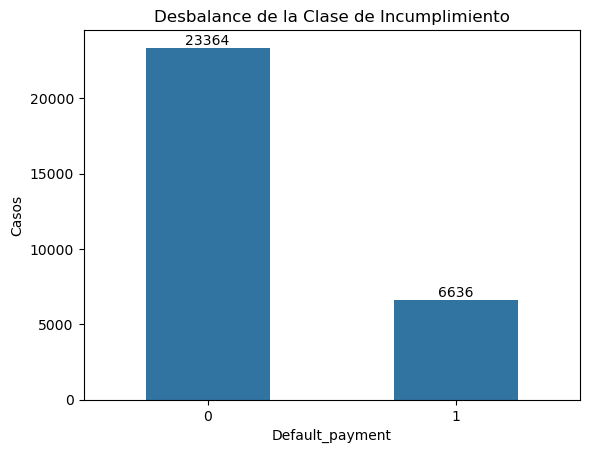

In [22]:
import seaborn as sns
plt.title("Desbalance de la Clase de Incumplimiento")
plt.ylabel("Casos")
ax = sns.countplot(data = df, x="Default_payment", width=0.5)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

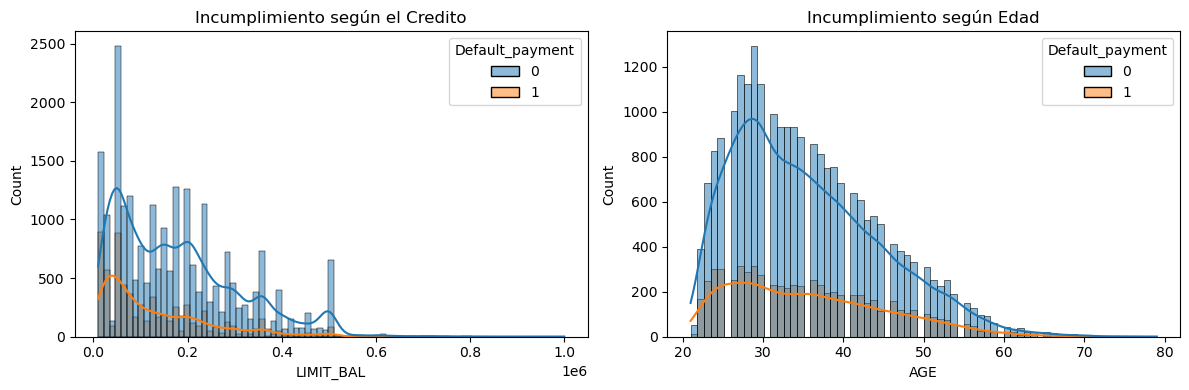

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data = df,
    x = "LIMIT_BAL",
    hue = "Default_payment",
    kde = True,
    ax = axes[0]
)
axes[0].set_title("Incumplimiento según el Credito")

sns.histplot(
    data=df,
    x="AGE",
    hue="Default_payment",
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Incumplimiento según Edad")

plt.tight_layout()
plt.show()

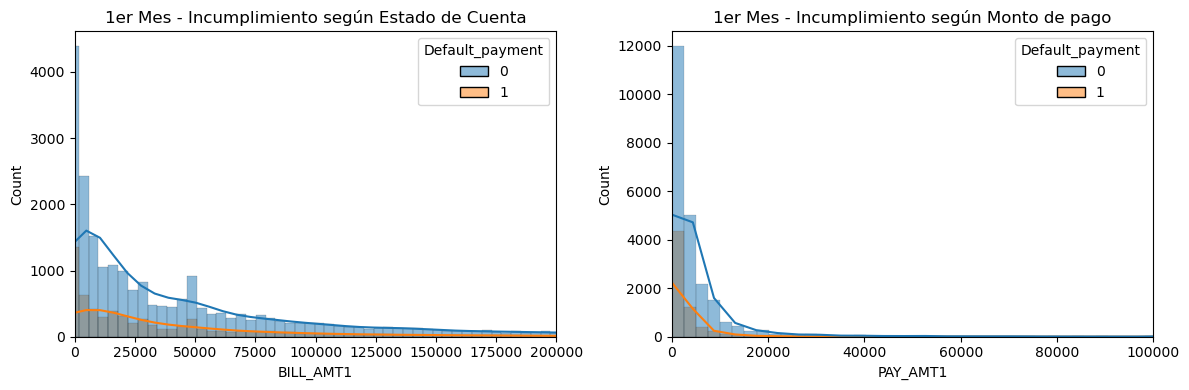

In [24]:
fig, axes = plt.subplots(1, 2, figsize= (12, 4))

sns.histplot(
    data=df,
    x = "BILL_AMT1",
    hue = "Default_payment",
    kde=True,
    ax = axes[0]
)
axes[0].set_title("1er Mes - Incumplimiento según Estado de Cuenta")

sns.histplot(
    data=df,
    x="PAY_AMT1",
    hue="Default_payment",
    kde=True,
    ax= axes[1]
)
axes[1].set_title("1er Mes - Incumplimiento según Monto de pago")

axes[0].set_xlim(0, 200000)
axes[1].set_xlim(0, 100000)
plt.tight_layout()
plt.show()

La mayoría de las variables numéricas presenta un marcado sesgo positivo, con colas derechas largas producidas por valores atípicos en las variables monetarias. Estos valores atípicos —concentrados en variables como el límite de crédito y los montos de pago— corresponden a clientes reales con actividad financiera inusual, y no a errores de captura de datos, por lo que se conservaron para evitar descartar observaciones potencialmente informativas.


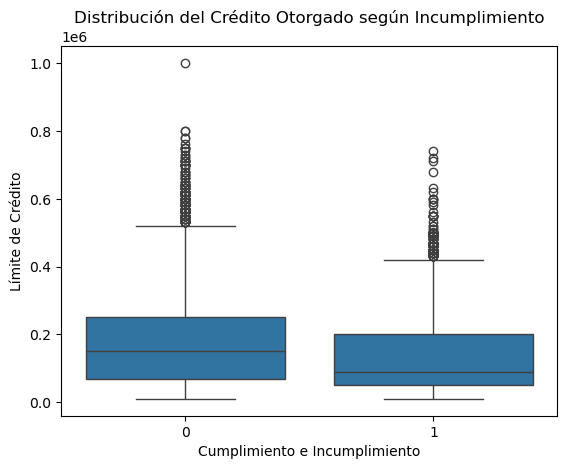

In [25]:
sns.boxplot(data=df, x="Default_payment", y="LIMIT_BAL")
plt.title("Distribución del Crédito Otorgado según Incumplimiento")
plt.xlabel("Cumplimiento e Incumplimiento")
plt.ylabel("Límite de Crédito")
plt.show()

In [26]:
Q1 = df["LIMIT_BAL"].quantile(0.25)
Q3 = df["LIMIT_BAL"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["LIMIT_BAL"] < lower) | (df["LIMIT_BAL"] > upper)]

print(f"Number of outliers: {len(outliers)}")
print(f"Percentage: {len(outliers)/len(df)*100:.2f}%")

Number of outliers: 167
Percentage: 0.56%


In [27]:
from scipy.stats import mannwhitneyu

default = df[df["Default_payment"] == 1]

non_default = df[df["Default_payment"] == 0]

stat, p = mannwhitneyu(
    default["LIMIT_BAL"],
    non_default["LIMIT_BAL"]
)

print(p)

1.2255485818223303e-189


Aunque **LIMIT_BAL** presenta numerosas observaciones fuera del rango intercuartílico (IQR), estos valores corresponden a clientes legítimos con límites de crédito inusualmente altos y no a errores de captura. Dado que la prueba de **Mann–Whitney U** confirmó una diferencia significativa entre las distribuciones del límite de crédito de clientes en incumplimiento y sin incumplimiento, estas observaciones se conservaron para el análisis posterior.


In [28]:
corr = df.corr(numeric_only = True)

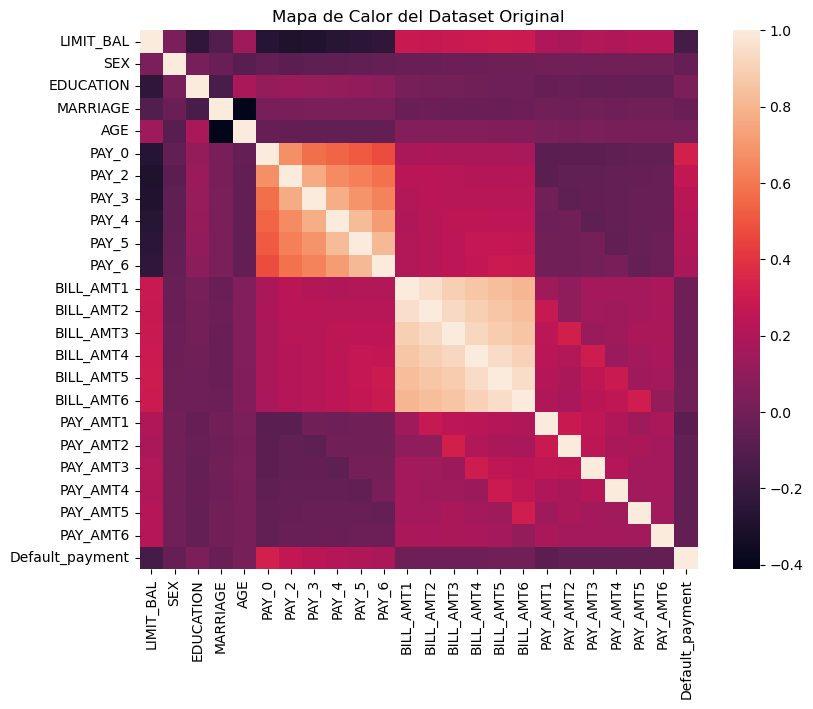

In [29]:
plt.figure(figsize = (9,7))
plt.title("Mapa de Calor del Dataset Original")
sns.heatmap(corr)
plt.show()

Las variables de facturación (**BILL_AMT1–BILL_AMT6**) presentan correlaciones positivas fuertes entre sí, lo que indica una multicolinealidad considerable. Si bien esto no afecta a los modelos basados en árboles, sí puede afectar la estabilidad de los coeficientes en Regresión Logística. Esta observación motivó la exploración de variables agregadas de facturación en la etapa de ingeniería de características.


### Hallazgos Clave
1. El dataset presenta un desbalance moderado (≈22% de casos de incumplimiento).
2. Los clientes con límites de crédito más bajos tienden a presentar tasas de incumplimiento más altas.
3. Las variables de historial de pago (*PAY_\**) muestran la relación más fuerte con la variable objetivo.
4. Los montos mensuales consecutivos de facturación (*BILL_AMT\**) están altamente correlacionados entre sí.


### 3. Ingeniería de Características


In [30]:
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

df_bsn = df.copy()

df_bsn["Delinq_month_count"] = (
    (df[pay_cols] > 0).sum(axis=1)
)

AVG_BILL = df_bsn[bill_cols].mean(axis=1)

df_bsn["Utilization_ratio"] = (
    AVG_BILL / df["LIMIT_BAL"]
)
df.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default_payment
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


**Delinq_month_count**: se considera que un mes presenta mora si el estado de pago (*PAY_\**) fue mayor a 0. Esta variable cuenta la cantidad de meses, de un total de seis, en los que el cliente mostró atraso en su pago.

**Utilization_ratio**: proporción del crédito disponible que el cliente está utilizando, calculada como el monto promedio de facturación mensual dividido entre el límite de crédito (*LIMIT_BAL*).


In [31]:
df_mod = df.copy()
df_mod["AVG_payment"] = df_mod[pay_amt_cols].mean(axis=1)
df_mod["AVG_BILL"] = df_mod[bill_cols].mean(axis=1)
df_mod.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default_payment,AVG_payment,AVG_BILL
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,689,0,0,0,0,1,114.833333,1284.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,3261,0,1000,1000,1000,0,2000,1,833.333333,2846.166667
2,90000,2,2,2,34,0,0,0,0,0,...,15549,1518,1500,1000,1000,1000,5000,0,1836.333333,16942.166667
3,50000,2,2,1,37,0,0,0,0,0,...,29547,2000,2019,1200,1100,1069,1000,0,1398.000000,38555.666667
4,50000,1,2,1,57,-1,0,-1,0,0,...,19131,2000,36681,10000,9000,689,679,0,9841.500000,18223.166667


In [32]:
df_rmv = df_mod.copy()
cols_rmv = pay_amt_cols + bill_cols
df_rmv = df_rmv.drop(cols_rmv, axis=1)
df_rmv

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,Default_payment,AVG_payment,AVG_BILL
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,1,114.833333,1284.000000
1,120000,2,2,2,26,-1,2,0,0,0,2,1,833.333333,2846.166667
2,90000,2,2,2,34,0,0,0,0,0,0,0,1836.333333,16942.166667
3,50000,2,2,1,37,0,0,0,0,0,0,0,1398.000000,38555.666667
4,50000,1,2,1,57,-1,0,-1,0,0,0,0,9841.500000,18223.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,0,0,7091.666667,120891.500000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,0,2415.000000,3530.333333
29997,30000,1,2,2,37,4,3,2,-1,0,0,1,5216.666667,11749.333333
29998,80000,1,3,1,41,1,-1,0,0,0,-1,1,24530.166667,44435.166667


### 4. Preprocesamiento de Datos


In [33]:
train, val, test = train_val_test_split(df, stratify="Default_payment")

X_train_base, y_train_base = feat_div(train, 'Default_payment')
X_val_base, y_val_base = feat_div(val, 'Default_payment')
X_test_base, y_test_base = feat_div(test, 'Default_payment')

train_set, val_set, test_set = train_val_test_split(df_bsn, stratify="Default_payment")

X_train, y_train = feat_div(train_set, 'Default_payment')
X_val, y_val = feat_div(val_set, 'Default_payment')
X_test, y_test = feat_div(test_set, 'Default_payment')

train_mod_set, val_mod_set, test_mod_set = train_val_test_split(df_mod, stratify="Default_payment")

X_train_m, y_train_m = feat_div(train_mod_set, 'Default_payment')
X_val_m, y_val_m = feat_div(val_mod_set, 'Default_payment')
X_test_m, y_test_m = feat_div(test_mod_set, 'Default_payment')

train_r_set, val_r_set, test_r_set = train_val_test_split(df_rmv, stratify="Default_payment")

X_train_r, y_train_r = feat_div(train_r_set, 'Default_payment')
X_val_r, y_val_r = feat_div(val_r_set, 'Default_payment')
X_test_r, y_test_r = feat_div(test_r_set, 'Default_payment')

**Hipótesis**: se construyeron tres conjuntos de variables, de forma progresiva, para evaluar si distintas estrategias de ingeniería de características mejoran el desempeño predictivo.

- **Baseline**: el dataset original, sin variables adicionales, pero con las etiquetas de *Education* y *Marriage* ya corregidas.
- **Dataset 1**: el baseline enriquecido con dos variables construidas (*Utilization_ratio* y *Delinq_month_count*).
- **Dataset 2**: Dataset 1 con dos variables agregadas adicionales (monto promedio de pago, *AVG_payment*, y monto promedio de facturación, *AVG_BILL*).
- **Dataset 3**: Dataset 2 sin las columnas mensuales originales de facturación (*BILL_AMT1–6*) y de monto de pago (*PAY_AMT1–6*), para evaluar si una representación más compacta conserva el desempeño predictivo.


### 5. Modelos Base (Baseline)


### 5.1 Regresión Logística Base


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve 

base_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

base_lr.fit(X_train_base, y_train_base)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [35]:
y_pred = base_lr.predict(X_val_base)

print("El F1-score base para Regresión Logística es:", f1_score(y_val_base, y_pred))
print(classification_report(y_val_base, y_pred))
print(confusion_matrix(y_val_base, y_pred))

El F1-score base para Regresión Logística es: 0.4774699132381752
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000

[[3280 1393]
 [ 474  853]]


### 5.2 Random Forest Base


In [36]:
from sklearn.ensemble import RandomForestClassifier

base_rf = RandomForestClassifier(n_estimators=60, random_state = 137, n_jobs=-1, class_weight = "balanced")
base_rf.fit(X_train_base, y_train_base)

,n_estimators,60
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_pred = base_rf.predict(X_val_base)

print("El F1-score base para Random Forest es:", f1_score(y_val_base, y_pred))
print(classification_report(y_val_base, y_pred))
print(confusion_matrix(y_val_base, y_pred))

El F1-score base para Random Forest es: 0.45007451564828616
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000

[[4440  233]
 [ 874  453]]


La comparación de los modelos base muestra un **F1-score** ligeramente más alto para la clase de incumplimiento con Regresión Logística que con Random Forest. Sin embargo, Random Forest presenta un promedio ponderado más alto entre ambas clases, lo que refleja una mayor capacidad para clasificar correctamente a los clientes que no incumplen.


### 6. Modelo de Regresión Logística


### 6.1 Dataset 1 — Desempeño del Modelo


In [38]:
lr_default_std = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_rbt = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_std.fit(X_train, y_train)
lr_default_rbt.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,penalty,'l2'
,dual,False


In [39]:
y_pred_std = lr_default_std.predict(X_val)
y_pred_rbt = lr_default_rbt.predict(X_val)

In [40]:
print("Escalador Estándar:")
print(classification_report(y_val, y_pred_std))
print(confusion_matrix(y_val, y_pred_std))

print("Escalador Robusto:")
print(classification_report(y_val, y_pred_rbt))
print(confusion_matrix(y_val, y_pred_rbt))

Escalador Estándar:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.47      0.58      0.52      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.76      0.77      6000

[[3799  874]
 [ 560  767]]
Escalador Robusto:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.47      0.58      0.52      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.76      0.77      6000

[[3800  873]
 [ 560  767]]


### 6.2 Dataset 2 — Desempeño del Modelo


In [41]:
lr_default_std_m = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_rbt_m = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_std_m.fit(X_train_m, y_train_m)
lr_default_rbt_m.fit(X_train_m, y_train_m)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,penalty,'l2'
,dual,False


In [42]:
y_pred_std_m = lr_default_std_m.predict(X_val_m)
y_pred_rbt_m = lr_default_rbt_m.predict(X_val_m)

In [43]:
print("Escalador Estándar:")
print(classification_report(y_val_m, y_pred_std_m))
print(confusion_matrix(y_val_m, y_pred_std_m))

print("Escalador Robusto:")
print(classification_report(y_val_m, y_pred_rbt_m))
print(confusion_matrix(y_val_m, y_pred_rbt_m))

Escalador Estándar:
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000

[[3279 1394]
 [ 475  852]]
Escalador Robusto:
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000

[[3278 1395]
 [ 474  853]]


### 6.3 Dataset 3 — Desempeño del Modelo


In [44]:
lr_default_std_r = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_rbt_r = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_std_r.fit(X_train_r, y_train_r)
lr_default_rbt_r.fit(X_train_r, y_train_r)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,penalty,'l2'
,dual,False


In [45]:
y_pred_std_r = lr_default_std_r.predict(X_val_r)
y_pred_rbt_r = lr_default_rbt_r.predict(X_val_r)

In [46]:
print("Escalador Estándar:")
print(classification_report(y_val_r, y_pred_std_r))
print(confusion_matrix(y_val_r, y_pred_std_r))

print("Escalador Robusto:")
print(classification_report(y_val_r, y_pred_rbt_r))
print(confusion_matrix(y_val_r, y_pred_rbt_r))

Escalador Estándar:
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000

[[3277 1396]
 [ 478  849]]
Escalador Robusto:
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000

[[3275 1398]
 [ 478  849]]


La incorporación de las variables agregadas de facturación y pagos (**Dataset 2**) produjo resultados comparables al baseline, lo que sugiere que estas variables agregadas aportan redundancia en lugar de información complementaria. **Dataset 1**, en cambio, obtuvo métricas más altas, lo que indica que *Delinq_month_count* y *Utilization_ratio* aportan información predictiva que las variables originales no capturaban por sí solas.


### 7. Modelo Random Forest


### 7.1 Dataset 1 (RF) — Desempeño del Modelo


In [47]:
clf_rnd = RandomForestClassifier(n_estimators=60, random_state = 137, n_jobs=-1, class_weight = "balanced")
clf_rnd.fit(X_train, y_train)

,n_estimators,60
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
y_pred = clf_rnd.predict(X_val)

In [49]:
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))
print("F1-score del dataset original:", f1_score(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000

[[4435  238]
 [ 870  457]]
F1-score del dataset original: 0.4520276953511375


### 7.2 Dataset 2 (RF) — Desempeño del Modelo


In [50]:
clf_rnd_m = RandomForestClassifier(n_estimators=50, random_state = 137, n_jobs=-1, class_weight = "balanced")
clf_rnd_m.fit(X_train_m, y_train_m)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
y_pred_m = clf_rnd_m.predict(X_val_m)

In [52]:
print(classification_report(y_val_m, y_pred_m))
print(confusion_matrix(y_val_m, y_pred_m))
print("F1-score del dataset 2:", f1_score(y_val_m, y_pred_m))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.66      0.34      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.64      0.67      6000
weighted avg       0.80      0.81      0.79      6000

[[4442  231]
 [ 881  446]]
F1-score del dataset 2: 0.44510978043912175


### 7.3 Dataset 3 (RF) — Desempeño del Modelo


In [53]:
clf_rnd_r = RandomForestClassifier(n_estimators=50, random_state = 137, n_jobs=-1, class_weight = "balanced")
clf_rnd_r.fit(X_train_r, y_train_r)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred_r = clf_rnd_r.predict(X_val_r)

In [55]:
print(classification_report(y_val_r, y_pred_r))
print(confusion_matrix(y_val_r, y_pred_r))
print("F1-score del dataset 3:", f1_score(y_val_r, y_pred_r))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.64      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

[[4417  256]
 [ 869  458]]
F1-score del dataset 3: 0.4487996080352768


Random Forest, en cambio, muestra un comportamiento consistente entre los distintos conjuntos de características: el **F1-score** de la clase de incumplimiento varía como máximo en 0.01 entre ellos. A partir de estos resultados, se seleccionó Dataset 1 como conjunto de trabajo: mejora ligeramente el **F1-score** de Regresión Logística, mientras que para Random Forest no genera una diferencia relevante.


### 8. Importancia de Variables


In [56]:
clf_rnd_fi = RandomForestClassifier(n_estimators=60, random_state = 137, n_jobs=-1, class_weight = "balanced")
clf_rnd_fi.fit(X_train, y_train)

clf_rnd_fi.feature_importances_

array([0.05268857, 0.0101922 , 0.01783394, 0.01153069, 0.05796527,
       0.0770656 , 0.02909619, 0.0250148 , 0.01241048, 0.01568328,
       0.01074508, 0.05642583, 0.04935006, 0.04540958, 0.04359411,
       0.04487233, 0.04380578, 0.04586716, 0.04835754, 0.04491286,
       0.04213947, 0.03994078, 0.04359447, 0.06725703, 0.06424691])

In [57]:
# Seleccionar las 13 variables más importantes para construir un conjunto reducido de variables.
feature_importances = {
    name: score
    for name, score in zip(X_train.columns, clf_rnd_fi.feature_importances_)
}

In [58]:
features_impo_sorted = pd.Series(feature_importances).sort_values(ascending=False)
features_impo_sorted.head(13)

PAY_0                 0.077066
Delinq_month_count    0.067257
Utilization_ratio     0.064247
AGE                   0.057965
BILL_AMT1             0.056426
LIMIT_BAL             0.052689
BILL_AMT2             0.049350
PAY_AMT2              0.048358
PAY_AMT1              0.045867
BILL_AMT3             0.045410
PAY_AMT3              0.044913
BILL_AMT5             0.044872
BILL_AMT6             0.043806
dtype: float64

In [59]:
columns = list(features_impo_sorted.head(13).index)
columns

['PAY_0',
 'Delinq_month_count',
 'Utilization_ratio',
 'AGE',
 'BILL_AMT1',
 'LIMIT_BAL',
 'BILL_AMT2',
 'PAY_AMT2',
 'PAY_AMT1',
 'BILL_AMT3',
 'PAY_AMT3',
 'BILL_AMT5',
 'BILL_AMT6']

In [60]:
'Default_payment' in X_train.columns

False

In [61]:
X_train_reduced = X_train[columns].copy()
X_val_reduced = X_val[columns].copy()

### 8.1 Regresión Logística — Conjunto de Variables Reducido


In [62]:
lr_default_if = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_if.fit(X_train_reduced, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [63]:
y_pred_rd_lr = lr_default_if.predict(X_val_reduced)

In [64]:
print(classification_report(y_val, y_pred_rd_lr))
print(confusion_matrix(y_val, y_pred_rd_lr))
print("F1-score Regresión Logística, variables importantes:", f1_score(y_val, y_pred_rd_lr))

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.47      0.58      0.52      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.76      0.77      6000

[[3799  874]
 [ 559  768]]
F1-score Regresión Logística, variables importantes: 0.5173459077130347


### 8.2 Random Forest — Conjunto de Variables Reducido


In [65]:
clf_rf_if = RandomForestClassifier(n_estimators= 60, random_state = 137, n_jobs=-1, class_weight = "balanced")
clf_rf_if.fit(X_train_reduced, y_train)

,n_estimators,60
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred_rd = clf_rf_if.predict(X_val_reduced)

In [67]:
print(classification_report(y_val, y_pred_rd))
print(confusion_matrix(y_val, y_pred_rd))
print("F1-score Random Forest, variables importantes:", f1_score(y_val, y_pred_rd))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.65      0.34      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000

[[4426  247]
 [ 878  449]]
F1-score Random Forest, variables importantes: 0.4438952051408799


Estos resultados sugieren que restringir el modelo únicamente a las variables más importantes no es necesariamente ventajoso: las variables descartadas podrían seguir aportando información complementaria que no capturan los principales predictores.


### 9. Validación Cruzada


In [68]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

### 9.1 Validación Cruzada — Dataset 1


In [69]:
cv = StratifiedKFold(
    n_splits = 5, shuffle=True, random_state=137
)

lr_score = cross_val_score(
    lr_default_std, X_train, y_train, cv=cv, scoring="f1"
)

rf_score = cross_val_score(
    clf_rnd, X_train, y_train, cv=cv, scoring="f1"
)

In [70]:
print("Regresión Logística:")
print("F1-scores:", lr_score)
print("Media:", lr_score.mean())
print("Desv. estándar:", lr_score.std())

Regresión Logística:
F1-scores: [0.53340883 0.51186441 0.52114286 0.53045404 0.51926298]
Media: 0.5232266242202182
Desv. estándar: 0.00781108812697569


In [71]:
print("Random Forest")
print("F1-scores:", rf_score)
print("Media:", rf_score.mean())
print("Desv. estándar:", rf_score.std())

Random Forest
F1-scores: [0.44717445 0.42389525 0.45513866 0.44070648 0.44259567]
Media: 0.4419021026161121
Desv. estándar: 0.01028748076438531


### 9.2 Validación Cruzada — Conjunto de Variables Reducido


In [72]:
cv = StratifiedKFold(
    n_splits = 5, shuffle=True, random_state=137
)

lr_score_rd = cross_val_score(
    lr_default_if, X_train_reduced, y_train, cv=cv, scoring="f1"
)

rf_score_rd = cross_val_score(
    clf_rf_if, X_train_reduced, y_train, cv=cv, scoring="f1"
)

In [73]:
print("Regresión Logística")
print("F1-scores:", lr_score_rd)
print("Media:", lr_score_rd.mean())
print("Desv. estándar:", lr_score_rd.std())

Regresión Logística
F1-scores: [0.52796421 0.50669643 0.52998287 0.53340635 0.51616499]
Media: 0.522842969686098
Desv. estándar: 0.009940788661829491


In [74]:
print("Random Forest")
print("F1-scores:", rf_score_rd)
print("Media:", rf_score_rd.mean())
print("Desv. estándar:", rf_score_rd.std())

Random Forest
F1-scores: [0.46672013 0.4379085  0.44644317 0.43564356 0.44498778]
Media: 0.4463406273968199
Desv. estándar: 0.010979005124056094


Reducir el espacio de variables a los predictores más importantes produjo un desempeño de validación cruzada prácticamente idéntico. Si bien el conjunto reducido no generó una mejora relevante en el F1-score, sí sugiere que la mayor parte de la información predictiva se concentra en un subconjunto relativamente pequeño de variables. Por lo tanto, la selección de variables podría ser útil para mejorar la simplicidad y la interpretabilidad del modelo sin comprometer el desempeño predictivo.


### 10. Optimización de Hiperparámetros (Grid Search)


In [75]:
param_grid_lr = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["lbfgs", "liblinear"],
    "model__max_iter": [1000]
}

In [76]:
from sklearn.model_selection import GridSearchCV

grid_search_lr = GridSearchCV(
    estimator=lr_default_std,
    param_grid=param_grid_lr,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

In [77]:
grid_search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step..._iter=2000))])
,param_grid,"{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__max_iter': [1000], 'model__solver': ['lbfgs', 'liblinear']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [78]:
print(grid_search_lr.best_params_)
print(grid_search_lr.best_score_)

{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
0.5238450883675166


In [79]:
best_lr = grid_search_lr.best_estimator_

In [80]:
param_grid = {
    "n_estimators": [75, 100, 125],
    "max_depth": [8, 10, 12],
    "min_samples_split": [2, 3],
    "min_samples_leaf": [4, 5, 6],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"]
}

In [81]:
grid_search = GridSearchCV(
    estimator=clf_rnd,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

In [82]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,estimator,RandomForestC...dom_state=137)
,param_grid,"{'class_weight': ['balanced'], 'max_depth': [8, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [4, 5, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [83]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
0.5415225226008665


In [84]:
best_rf = grid_search.best_estimator_

### 11. Optimización del Umbral de Decisión


### 11.1 Regresión Logística — Mejor Estimador


In [85]:
y_prob_lr = best_lr.predict_proba(X_val)[:,1]

precision, recall, threshold = precision_recall_curve(y_val, y_prob_lr)

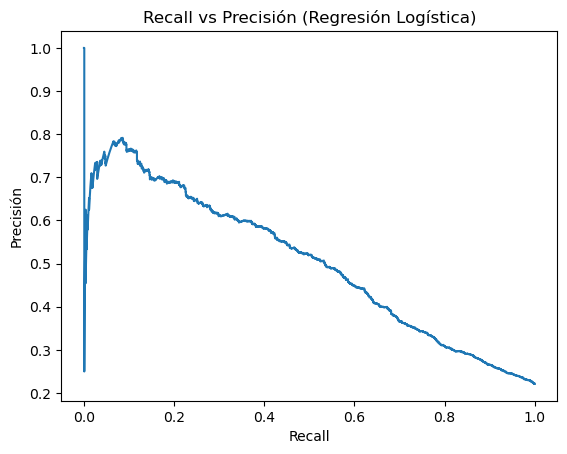

In [86]:
F1_score = np.divide(
    2 * precision[:-1] * recall[:-1],
    precision[:-1] + recall[:-1],
    out=np.zeros_like(precision[:-1]),
    where=(precision[:-1] + recall[:-1]) != 0
)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precisión")
plt.title("Recall vs Precisión (Regresión Logística)")
plt.show()

In [87]:
print(F1_score.max())
print(threshold[np.argmax(F1_score)])

0.5209270148737462
0.5181169096265469


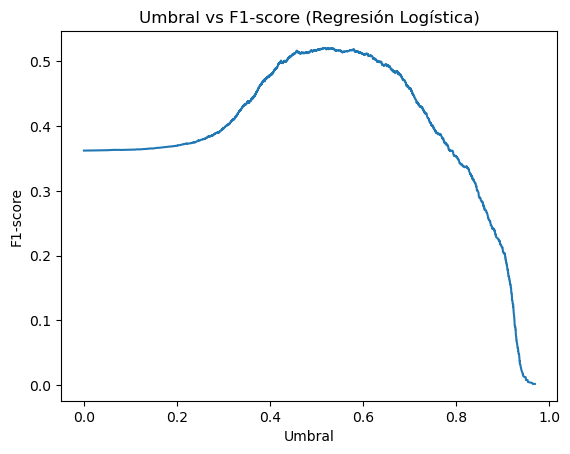

In [88]:
plt.plot(threshold, F1_score)
plt.xlabel("Umbral")
plt.ylabel("F1-score")
plt.title("Umbral vs F1-score (Regresión Logística)")
plt.show()

In [89]:
best_idx = np.argmax(F1_score)
best_threshold = threshold[best_idx]
best_threshold

np.float64(0.5181169096265469)

In [90]:
y_pred_lr = (y_prob_lr >= best_threshold).astype(int)

print(classification_report(y_val, y_pred_lr))
print(confusion_matrix(y_val, y_pred_lr))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.48      0.57      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.70      0.68      6000
weighted avg       0.78      0.77      0.78      6000

[[3862  811]
 [ 574  753]]


### 11.2 Random Forest — Mejor Estimador


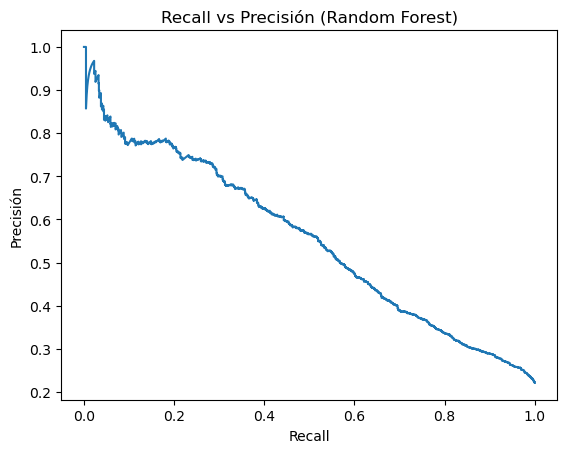

In [91]:
y_prob_rf = best_rf.predict_proba(X_val)[:,1]

precision_rf, recall_rf, threshold_rf = precision_recall_curve(y_val, y_prob_rf)

plt.plot(recall_rf, precision_rf)
plt.xlabel("Recall")
plt.ylabel("Precisión")
plt.title("Recall vs Precisión (Random Forest)")
plt.show()

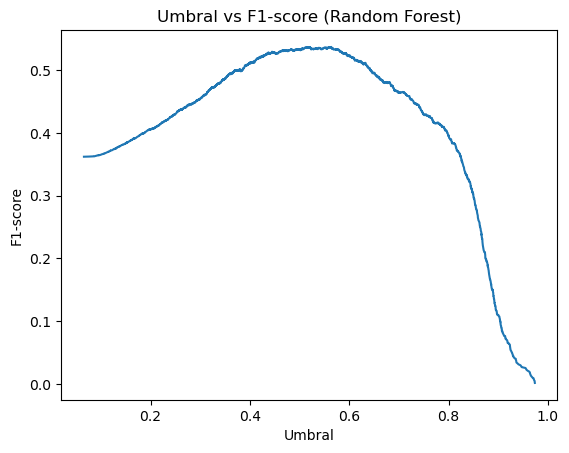

In [92]:
F1_score_rf = np.divide(
    2 * precision_rf[:-1] * recall_rf[:-1],
    precision_rf[:-1] + recall_rf[:-1],
    out=np.zeros_like(precision_rf[:-1]),
    where=(precision_rf[:-1] + recall_rf[:-1]) != 0
)

plt.plot(threshold_rf, F1_score_rf)
plt.xlabel("Umbral")
plt.ylabel("F1-score")
plt.title("Umbral vs F1-score (Random Forest)")
plt.show()

In [93]:
best_idx = np.argmax(F1_score_rf)
best_threshold_rf = threshold_rf[best_idx]

y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)

In [94]:
print(classification_report(y_val, y_pred_rf))
print(confusion_matrix(y_val, y_pred_rf))
print(f1_score(y_val, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      4673
           1       0.56      0.52      0.54      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.70      0.71      6000
weighted avg       0.80      0.80      0.80      6000

[[4138  535]
 [ 643  684]]
0.5373134328358209


### 12. Evaluación Final en el Conjunto de Prueba


### 12.1 Regresión Logística — Evaluación en el Conjunto de Prueba


In [95]:
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

X_train_full = X_train_full.reset_index(drop=True)
y_train_full = y_train_full.reset_index(drop=True)

In [96]:
best_lr.fit(X_train_full, y_train_full)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01


In [97]:
y_prob_lr = best_lr.predict_proba(X_test)[:,1]

y_pred_lr = (y_prob_lr >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(f1_score(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4673
           1       0.50      0.58      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.69      6000
weighted avg       0.79      0.78      0.78      6000

[[3885  788]
 [ 552  775]]
0.5363321799307958


### 12.2 Random Forest — Evaluación en el Conjunto de Prueba


In [98]:
best_rf.fit(X_train_full, y_train_full)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(f1_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      4673
           1       0.57      0.54      0.55      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.71      0.72      6000
weighted avg       0.80      0.81      0.81      6000

[[4137  536]
 [ 612  715]]
0.5546935608999224


### 13. Conclusiones


Este proyecto desarrolló un pipeline completo de machine learning para la predicción de incumplimiento de pago en tarjetas de crédito, cubriendo el análisis exploratorio de datos, la ingeniería de características, el desarrollo de modelos, la optimización de hiperparámetros y una evaluación no sesgada sobre un conjunto de prueba no visto. A lo largo de los experimentos surgieron varios hallazgos relevantes.

**Ingeniería de características**: no todas las variables construidas mejoraron el desempeño predictivo. Las variables orientadas al negocio, como *Utilization_ratio* y *Delinq_month_count*, se incorporaron con éxito a los modelos. Sin embargo, la introducción de promedios agregados de facturación y pagos redujo el desempeño de forma notoria, lo que sugiere que el historial financiero mensual detallado contiene información temporal valiosa que no puede resumirse adecuadamente mediante simples promedios.

**Selección de características**: simplificó el dataset sin afectar de manera relevante el desempeño. Utilizar únicamente los predictores más informativos produjo puntajes de validación cruzada prácticamente idénticos a los obtenidos con el conjunto completo de variables. Aunque el conjunto reducido no mejoró significativamente el desempeño predictivo, sí evidenció que la mayor parte de la señal predictiva se concentra en un subconjunto relativamente pequeño de variables, lo que mejora la interpretabilidad sin sacrificar el desempeño.

**Regresión Logística** mostró un desempeño consistente entre la validación cruzada y el conjunto de prueba: su F1-score de validación cruzada tras la optimización de hiperparámetros (0.524) y su F1-score en el conjunto de prueba (0.536) fueron muy similares, lo que indica una buena capacidad de generalización.

**Random Forest** alcanzó el F1-score más alto en el conjunto de prueba (**0.555**). En la validación cruzada inicial, con hiperparámetros por defecto, obtuvo puntajes menores que Regresión Logística (0.44 frente a 0.52); sin embargo, tras la optimización de hiperparámetros su F1 promedio en validación cruzada subió a 0.542 —ya por encima de Regresión Logística—, y la optimización del umbral de decisión permitió confirmar esa ventaja en el conjunto de prueba. Esto resalta la importancia de evaluar el pipeline completo de optimización antes de descartar un modelo, en lugar de basarse únicamente en su desempeño con hiperparámetros por defecto.

---

_Desde una perspectiva de negocio, un F1-score de 0.555 representa un balance razonable entre identificar clientes en riesgo de incumplimiento y limitar las falsas alarmas. Si bien el modelo no está pensado para reemplazar a los analistas de crédito, podría funcionar como una herramienta de apoyo a la decisión para priorizar la revisión de clientes de alto riesgo. En un entorno de producción, sería necesario un trabajo adicional —como calibración de probabilidades, aprendizaje sensible al costo, validación externa y reentrenamiento periódico— antes de su despliegue_.
